### Deezer Context-Aware Recommendation A/B Test Analysis
### 분석 목적
추천 카드(Recommendation) 기능 도입이 비즈니스적으로 성공했는가?
- Primary OEC: D+30 Retention Rate
- Secondary: Conversion Rate, CTR
- Business: Cannibalization, Net Click Growth

In [8]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ID = 'music-db-project-485112'
DATASET    = 'analytics'

client = bigquery.Client(project=PROJECT_ID, location='europe-west9')

In [9]:
# dbt mart 3개 로드
df_perf = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.fact_user_performance`
""").to_dataframe()

df_retention = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.fact_cohort_retention`
""").to_dataframe()

df_discovery = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.fact_discovery_journey`
""").to_dataframe()

print(f'fact_user_performance  : {df_perf.shape}')
print(f'fact_cohort_retention  : {df_retention.shape}')
print(f'fact_discovery_journey : {df_discovery.shape}')

fact_user_performance  : (20000, 11)
fact_cohort_retention  : (116, 6)
fact_discovery_journey : (3, 12)


In [10]:
df_discovery.head()

,user_group,section,total_sessions,total_clicks,ctr,total_plays,play_rate,avg_play_duration_sec,total_skips,skip_rate,total_likes,like_rate
0,control,recently_played,71719,15454,0.215480,12408,0.802899,134.8,3776,0.304320,1566,0.126209
1,treatment,recently_played,38100,6544,0.171759,5217,0.797219,135.1,1562,0.299406,614,0.117692
2,treatment,recommendation,37205,13039,0.350464,10407,0.798144,105.8,3193,0.306813,1271,0.122129


In [11]:
# ── SRM Check ─────────────────────────────────────────────────────
# Sample Ratio Mismatch: 실험 배정이 50:50으로 제대로 됐는지 확인
# 카이제곱 검정 사용

from scipy.stats import chisquare

ctrl_n = df_perf[df_perf.user_group == 'control'].shape[0]
trt_n  = df_perf[df_perf.user_group == 'treatment'].shape[0]
total  = ctrl_n + trt_n

expected = [total / 2, total / 2]
observed = [ctrl_n, trt_n]

chi2, p_srm = chisquare(f_obs=observed, f_exp=expected)

print('── SRM Check ──────────────────────────────────────')
print(f'  Control   : {ctrl_n:,}')
print(f'  Treatment : {trt_n:,}')
print(f'  Chi2      : {chi2:.4f}')
print(f'  p-value   : {p_srm:.4f}')
if p_srm < 0.05:
    print('  ⚠️  SRM 감지 — 실험 결과 신뢰 불가')
else:
    print('  ✅ SRM 없음 — 실험 배정 정상')
print('───────────────────────────────────────────────────')

── SRM Check ──────────────────────────────────────
  Control   : 10,000
  Treatment : 10,000
  Chi2      : 0.0000
  p-value   : 1.0000
  ✅ SRM 없음 — 실험 배정 정상
───────────────────────────────────────────────────


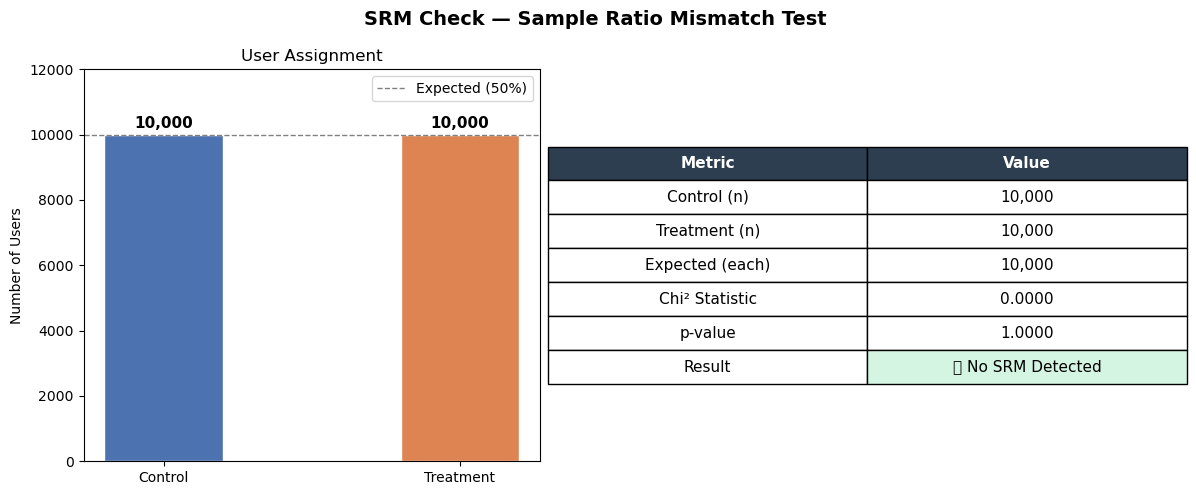

Saved -> srm_check.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SRM Check — Sample Ratio Mismatch Test', fontsize=14, fontweight='bold')

# ── 왼쪽: Bar chart ──────────────────────────────────────
ax1 = axes[0]
groups = ['Control', 'Treatment']
counts = [ctrl_n, trt_n]
colors = ['#4C72B0', '#DD8452']

bars = ax1.bar(groups, counts, color=colors, width=0.4, edgecolor='white')
ax1.set_title('User Assignment', fontsize=12)
ax1.set_ylabel('Number of Users')
ax1.set_ylim(0, max(counts) * 1.2)

for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.axhline(y=total/2, color='gray', linestyle='--', linewidth=1, label='Expected (50%)')
ax1.legend()

# ── 오른쪽: 결과 테이블 ───────────────────────────────────
ax2 = axes[1]
ax2.axis('off')

table_data = [
    ['Metric', 'Value'],
    ['Control (n)', f'{ctrl_n:,}'],
    ['Treatment (n)', f'{trt_n:,}'],
    ['Expected (each)', f'{int(total/2):,}'],
    ['Chi² Statistic', f'{chi2:.4f}'],
    ['p-value', f'{p_srm:.4f}'],
    ['Result', '✅ No SRM Detected'],
]

table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.0)

# 헤더 색상
for j in range(2):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Result 행 강조
table[6, 1].set_facecolor('#D5F5E3')

plt.tight_layout()
plt.savefig('srm_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> srm_check.png')